# 07. Tree Model Interpretation (SHAP)

## Purpose
We open the "Black Box" of our machine learning models.
We use **SHAP (Shapley Additive Explanations)** to understand exactly *why* a model flags a claim as fraud.

## What is SHAP?
Imagine the model's prediction is a "bill" that needs to be paid.
SHAP values tell us how much each feature (e.g., "Policy State", "Deductible") contributed to that bill.
*   **Positive SHAP**: Pushes the risk score UP (towards Fraud).
*   **Negative SHAP**: Pushes the risk score DOWN (towards Normal).

## Goals:
1.  **Global Trust**: Verify the model uses logical features (e.g., "Severity" should count more than "Color of car").
2.  **Individual Debugging**: Take a specific False Alarm and explain *why* the model got confused.


### Step 1: Setup and Load Data
**What:** Import `shap` library and load our Calibrated Models.
**Note:** SHAP calculations can be slow, so we focus only on the top-performing models.


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Add src to path
import sys
sys.path.append('../src')
from utils.data_loader import load_insurance_data

SEED = 42

/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data
datasets = {
    'Original': load_insurance_data('preprocessed', verbose=True),
    'Trees': load_insurance_data('trees', verbose=True)
}

# Load Calibrated Models
calibrated_models = joblib.load('../fraud-detector/models/best_tree_models_calibrated.joblib')
print("Loaded calibrated models.")

✓ Loading preprocessed dataset: insurance_claims_preprocessed_no_hobbies.csv
  Shape: (1000, 51)
  Target distribution: {0: 753, 1: 247}
  Fraud rate: 24.7%
✓ Loading trees dataset: preprocesed_for_trees.csv
  Shape: (1000, 43)
  Target distribution: {0: 753, 1: 247}
  Fraud rate: 24.7%
Loaded calibrated models.


### Step 2: The Interpretation Loop
This large cell performs multiple complex tasks for each model:

**A. Data Preparation (Pipeline Recovery)**:
The hardest part of SHAP is getting the feature names back!
The model converts "State: NY" into `[0, 0, 1, 0...]`. We have to reverse code or track these names carefully so the plot says "State=NY" and not "Feature 42".

**B. Global Plots (The Big Picture)**:
1.  **Beeswarm Plot**: The single best summary.
    *   **Y-axis**: Features ordered by importance.
    *   **Color**: Red = High value, Blue = Low value.
    *   **X-axis**: SHAP value (Impact on Risk).
    *   *Example*: If "Incident Severity" is Red and on the Right, it means "High Severity increases Fraud Risk".

**C. Interaction Plots**:
Does "Age" matter differently depending on "Gender"? These plots show those combinations.

**D. Individual "Forensics" (Waterfall/Force Plots)**:
We pick a specific claim (e.g., a False Positive) and break it down.
*   **Waterfall Plot**: Starts at the "Average Risk" and adds/subtracts bars for each feature until reaching the final Score.


In [25]:
# ============================================================
# MODULE A — MODEL + DATASET SELECTION
# ------------------------------------------------------------
# Team Rationale:
# - Keep model selection isolated so debugging is easy.
# - Allows swapping models or datasets without touching SHAP logic.
# ============================================================

# !!!
# SELECT MODEL & DATASET here:
# Models: "XGBoost", "RandomForest", "ExtraTrees"
# Datasets: "Trees", "Original"
# !!!

SEED = 42

dataset_name = "Trees"
model_name   = "RandomForest"

# ------------------------------------------------------------
# Validate selections BEFORE doing anything
# ------------------------------------------------------------
if dataset_name not in datasets:
    raise ValueError(f"Dataset '{dataset_name}' not found. Available: {list(datasets.keys())}")

if dataset_name not in calibrated_models:
    raise ValueError(f"Dataset '{dataset_name}' missing in calibrated_models dict.")

if model_name not in calibrated_models[dataset_name]:
    raise ValueError(
        f"Model '{model_name}' not available for dataset '{dataset_name}'.\n"
        f"Available models: {list(calibrated_models[dataset_name].keys())}"
    )

# ------------------------------------------------------------
# Create global readable label
# ------------------------------------------------------------
model_label = f"{model_name} on {dataset_name}"

print("\n==============================================")
print(f"SELECTED MODEL: {model_label}")
print("==============================================")

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df = datasets[dataset_name]
X  = df.drop("target", axis=1)
y  = df["target"]

# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# ------------------------------------------------------------
# Retrieve calibrated model + unwrap if needed
# ------------------------------------------------------------
calibrated_clf = calibrated_models[dataset_name][model_name]

if hasattr(calibrated_clf, "calibrated_classifiers_"):
    base_model = calibrated_clf.calibrated_classifiers_[0].estimator
else:
    base_model = calibrated_clf

print("Model type:", type(base_model).__name__)
print("Calibration wrapper detected:" , hasattr(calibrated_clf, "calibrated_classifiers_"))
print("Module A successfully initialized.\n")



SELECTED MODEL: RandomForest on Trees
Model type: Pipeline
Calibration wrapper detected: True
Module A successfully initialized.



In [26]:
# ============================================================
# MODULE B — PREPROCESSING & FEATURE NAMES
# ------------------------------------------------------------
# Team Rationale:
# - SHAP must use the **exact same transformed matrix** as the model.
# - Feature names often break due to ColumnTransformer internals.
# - This module guarantees: (1) same preprocessing, 
#   (2) correct dimensionality, (3) stable feature names.
# ============================================================

print(f"\n### MODULE B — Pipeline Extraction ({model_label}) ###\n")

# ------------------------------------------------------------
# 1. Detect pipeline structure
# ------------------------------------------------------------
if hasattr(base_model, "named_steps") and "prep" in base_model.named_steps:
    prep = base_model.named_steps["prep"]
    clf  = base_model.named_steps["clf"]

    print("Pipeline detected — applying 'prep' transformation...")

    # Transform
    X_train_t = prep.transform(X_train)
    X_test_t  = prep.transform(X_test)

    # Sparse → dense
    if hasattr(X_train_t, "toarray"):
        X_train_t = X_train_t.toarray()
        X_test_t  = X_test_t.toarray()

    # ------------------------------------------------------------
    # 2. Extract feature names robustly
    # ------------------------------------------------------------
    try:
        feature_names = list(prep.get_feature_names_out())
        print("Feature names extracted via get_feature_names_out().")
    except Exception as e:
        print("⚠️ Feature name extraction failed:", e)
        feature_names = [f"feature_{i}" for i in range(X_train_t.shape[1])]
        print("Fallback names applied.")

else:
    print("No pipeline detected — using raw features.")

    clf = base_model
    X_train_t = X_train.values
    X_test_t  = X_test.values
    feature_names = list(X_train.columns)

# ------------------------------------------------------------
# 3. Dimensionality sanity check
# ------------------------------------------------------------
if len(feature_names) != X_train_t.shape[1]:
    print("❌ Dimension mismatch detected!")
    print("Feature names:", len(feature_names))
    print("Transformed columns:", X_train_t.shape[1])
    raise RuntimeError(
        "Feature name count does not match transformed matrix size. "
        "This must be fixed before running SHAP."
    )

print(f"✓ Preprocessing OK — {len(feature_names)} features aligned with model.\n")



### MODULE B — Pipeline Extraction (RandomForest on Trees) ###

Pipeline detected — applying 'prep' transformation...
Feature names extracted via get_feature_names_out().
✓ Preprocessing OK — 171 features aligned with model.




### MODULE C — Global SHAP (RandomForest on Trees) ###


=== TOP GLOBAL DRIVERS (mean |SHAP|) ===
incident_severity_Major Damage           | SHAP = 0.2341
insured_hobbies_chess                    | SHAP = 0.0865
insured_hobbies_cross-fit                | SHAP = 0.0628
injury_share                             | SHAP = 0.0139
insured_occupation_exec-managerial       | SHAP = 0.0099
months_as_customer                       | SHAP = 0.0077
policy_annual_premium                    | SHAP = 0.0076
hour_cos                                 | SHAP = 0.0070
insured_occupation_handlers-cleaners     | SHAP = 0.0066
total_claim_amount                       | SHAP = 0.0058


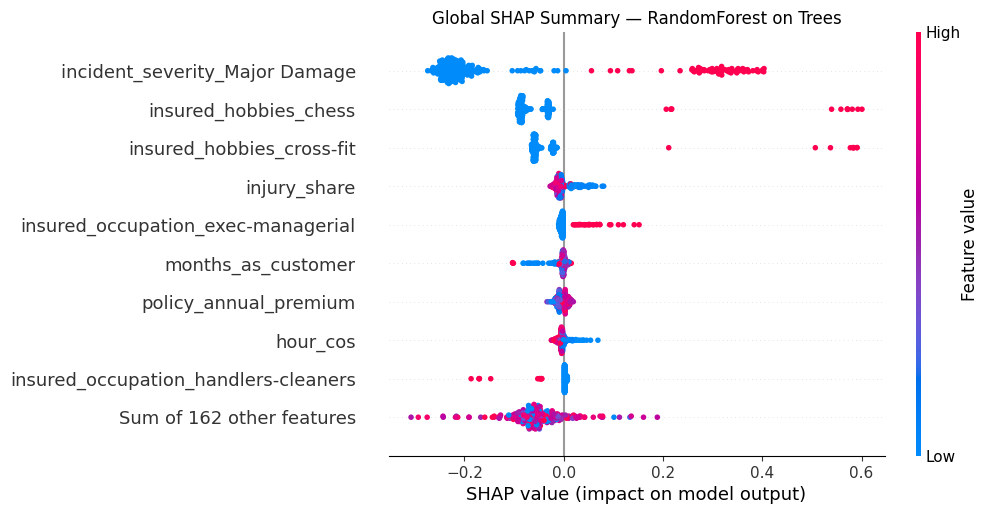


=== DEPENDENCE PLOTS (Explicit Continuous Features) ===
Dependence: policy_annual_premium


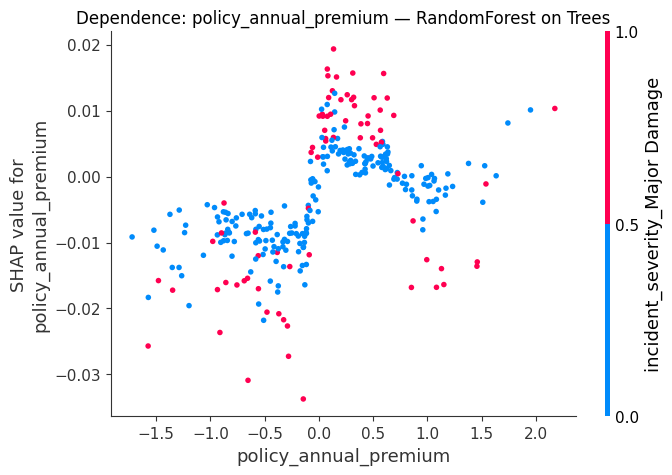

Dependence: days_since_bind


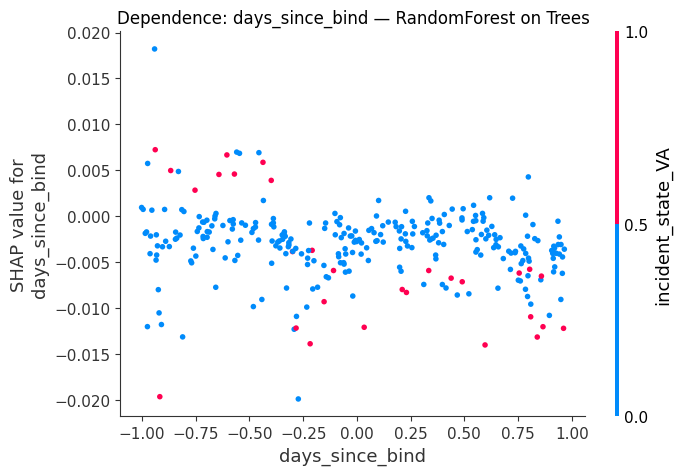

Dependence: total_claim_amount


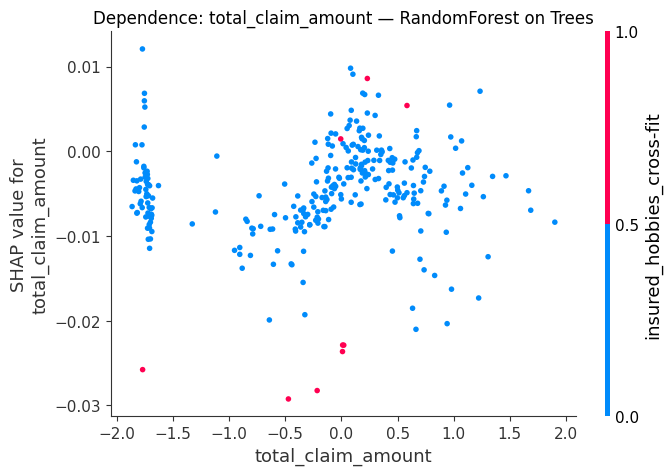

Dependence: months_as_customer


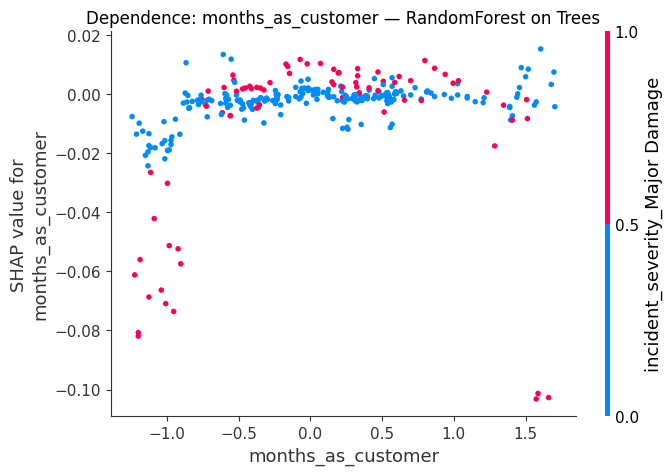

Dependence: capital-loss


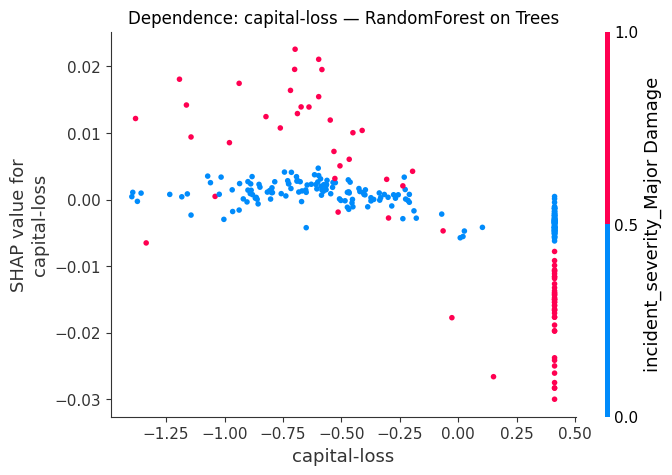

Dependence: capital-gains


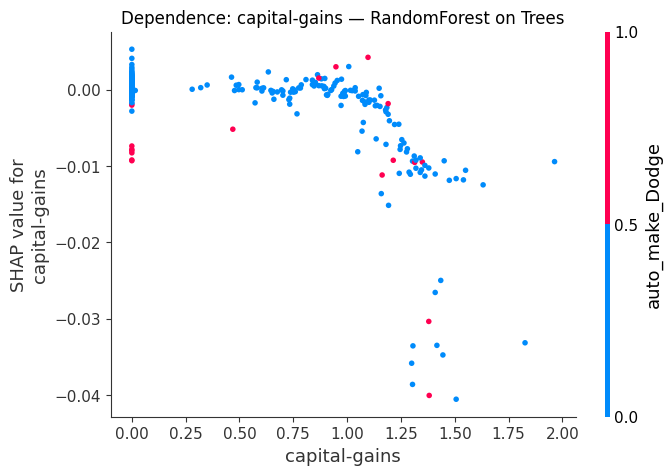

Dependence: age


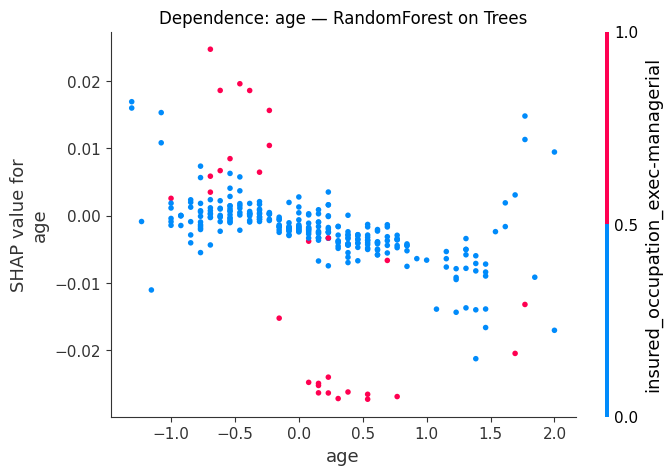

Dependence: incident_hour_of_the_day


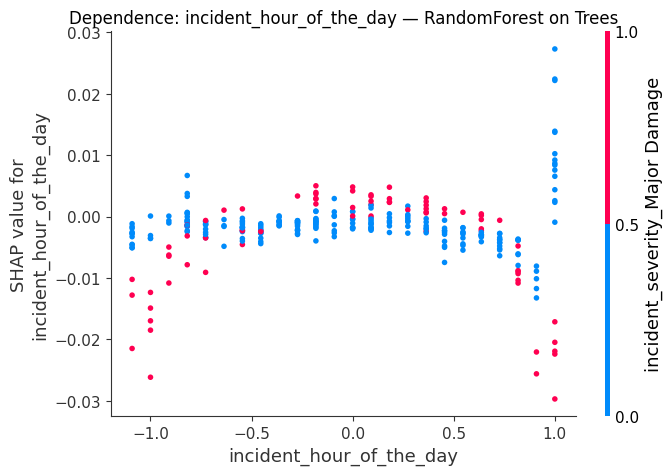

Dependence: hour_cos


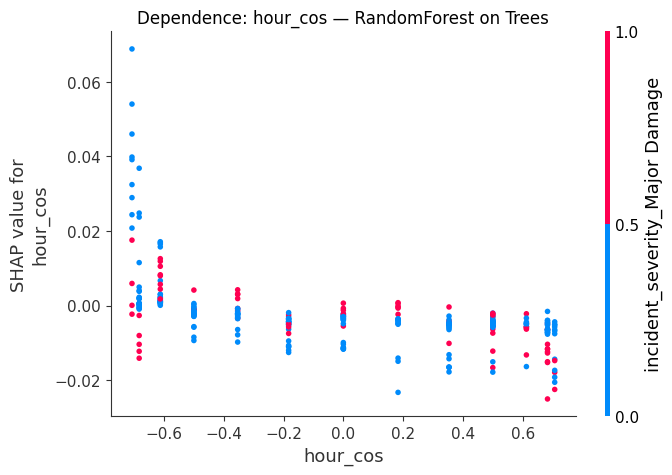

Dependence: hour_sin


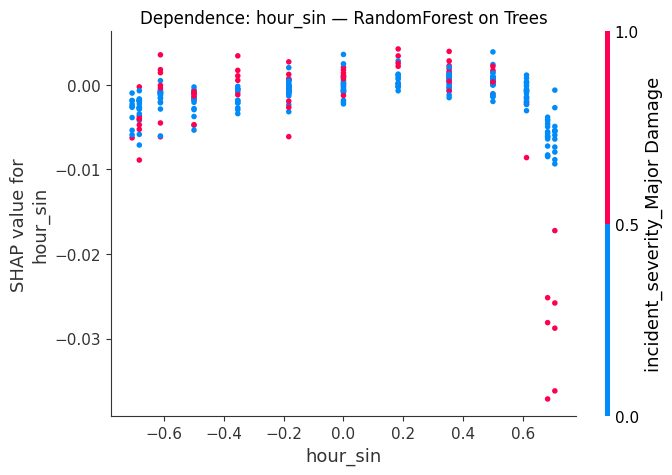

Dependence: vehicle_age


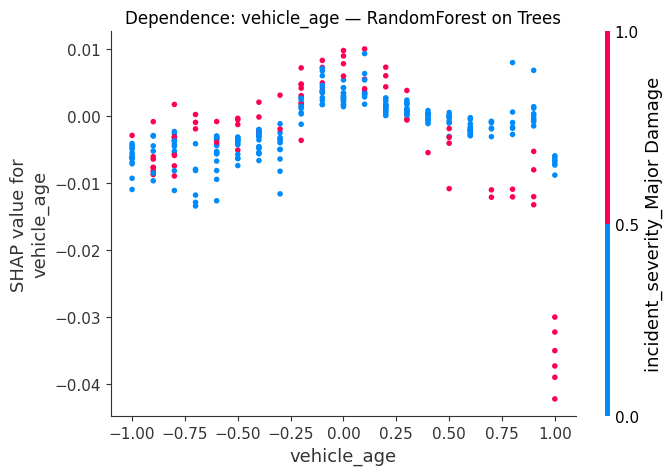

In [27]:
# ============================================================
# MODULE C — GLOBAL SHAP (Beeswarm, Top Drivers, Dependence)
# ------------------------------------------------------------
# Team Rationale:
# - Provides interpretable *global* model behavior.
# - This is what goes into the PRD and into your web UI decisions.
# - Separated from heavy per-case analysis for clarity.
# ============================================================

print(f"\n### MODULE C — Global SHAP ({model_label}) ###\n")

explainer = shap.TreeExplainer(clf)

# Subsample for speed (SHAP cost grows with N)
X_sub = X_train_t[:300]

# Compute SHAP
shap_raw = explainer(X_sub, check_additivity=False)

# Binary classifier shape fix
if len(shap_raw.shape) == 3:
    shap_global = shap_raw[:, :, 1]
else:
    shap_global = shap_raw

shap_global.feature_names = feature_names
shap_matrix = shap_global.values

# ---- Top drivers (team-facing narrative) ----
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
top_idx = np.argsort(-mean_abs_shap)[:10]

print("\n=== TOP GLOBAL DRIVERS (mean |SHAP|) ===")
for i in top_idx:
    print(f"{feature_names[i]:40s} | SHAP = {mean_abs_shap[i]:.4f}")

# ---- Beeswarm ----
plt.figure(figsize=(10,6))
plt.title(f"Global SHAP Summary — {model_label}")
shap.plots.beeswarm(shap_global, show=False)
plt.show()

# ------------------------------------------------------------
# DEPENDENCE PLOTS (Explicit Continuous Features)
# ------------------------------------------------------------

continuous_features = [
    "policy_annual_premium",
    "days_since_bind",
    "total_claim_amount",
    "months_as_customer",
    "capital-loss",
    "capital-gains",
    "age",
    "incident_hour_of_the_day",
    "hour_cos",
    "hour_sin",
    "vehicle_age"
]

print("\n=== DEPENDENCE PLOTS (Explicit Continuous Features) ===")

for fname in continuous_features:
    if fname in feature_names:
        idx = feature_names.index(fname)
        print(f"Dependence: {fname}")

        # Force our own title (SHAP ignores custom titles)
        shap.dependence_plot(idx, shap_matrix, X_sub, feature_names=feature_names, show=False)
        plt.title(f"Dependence: {fname} — {model_label}")
        plt.show()

    else:
        print(f"[SKIPPED] {fname} not in transformed feature list (maybe encoded differently).")


In [29]:
# ============================================================
# MODULE D — SHAP INTERACTIONS
# ------------------------------------------------------------
# Team Rationale:
# - Highlights nonlinear feature synergies.
# - Fraud patterns often arise from joint signals, not single variables.
# - Clear separation keeps global analysis readable.
# ============================================================

print(f"\n### MODULE D — SHAP Interaction Analysis ({model_label}) ###\n")

# ------------------------------------------------------------
# 1. Ensure explainer exists for this module
# ------------------------------------------------------------
try:
    explainer
except NameError:
    print("Reinitializing SHAP TreeExplainer for interactions...")
    explainer = shap.TreeExplainer(clf)

# ------------------------------------------------------------
# 2. Quick safety check
# ------------------------------------------------------------
n_features = X_train_t.shape[1]
if n_features > 250:
    print(f"⚠️ WARNING: High feature count ({n_features}). "
          "Interaction SHAP may be slow or memory-heavy.")

# ------------------------------------------------------------
# 3. Try computing interactions
# ------------------------------------------------------------
try:
    X_inter = X_train_t[:80]  # small batch

    inter_raw = explainer.shap_interaction_values(X_inter)

    # Fix shape for binary classifier
    if isinstance(inter_raw, list):
        inter_raw = inter_raw[1]
    if len(inter_raw.shape) == 4:
        inter_raw = inter_raw[:, :, :, 1]

    # Mean absolute interaction strength
    mean_interaction = np.abs(inter_raw).mean(axis=0)

    # Zero diagonal (self-interactions are useless)
    np.fill_diagonal(mean_interaction, 0)

    # Upper triangle only
    idx_upper = np.triu_indices_from(mean_interaction, k=1)

    # Build interaction list
    inter_records = [
        {
            "strength": mean_interaction[i, j],
            "f1": feature_names[i],
            "f2": feature_names[j]
        }
        for i, j in zip(*idx_upper)
    ]

    # Sort by strongest synergies
    inter_sorted = sorted(inter_records, key=lambda x: x["strength"], reverse=True)

    # Pick the top 10 interactions
    top_k = inter_sorted[:10]

    print("Top 10 Interactions (sorted by strength):\n")
    for rec in top_k:
        f1, f2, s = rec["f1"], rec["f2"], rec["strength"]

        # Narrative tags
        if s > 0.20:
            tag = "⚠️ Strong nonlinear synergy"
        elif s > 0.10:
            tag = "▪︎ Moderate joint effect"
        elif s > 0.05:
            tag = "• Weak but relevant interaction"
        else:
            tag = "• Very mild interaction"

        print(f"{f1:35s} × {f2:35s} | {s:.4f}   {tag}")

except Exception as e:
    print("❌ Interaction analysis skipped due to error:")
    print(e)



### MODULE D — SHAP Interaction Analysis (RandomForest on Trees) ###

Top 10 Interactions (sorted by strength):

insured_hobbies_chess               × incident_severity_Major Damage      | 0.0283   • Very mild interaction
insured_hobbies_cross-fit           × incident_severity_Major Damage      | 0.0238   • Very mild interaction
insured_hobbies_chess               × insured_hobbies_cross-fit           | 0.0064   • Very mild interaction
insured_occupation_handlers-cleaners × incident_severity_Major Damage      | 0.0059   • Very mild interaction
capital-loss                        × incident_severity_Major Damage      | 0.0047   • Very mild interaction
months_as_customer                  × incident_severity_Major Damage      | 0.0047   • Very mild interaction
injury_share                        × incident_severity_Major Damage      | 0.0041   • Very mild interaction
bodily_injuries                     × incident_severity_Major Damage      | 0.0035   • Very mild interaction
total_claim_a


### MODULE E — Case-Level SHAP Waterfalls (RandomForest on Trees) ###

Plotting 5 case waterfalls...

--- Fraud Case #1 (test idx = 1) ---


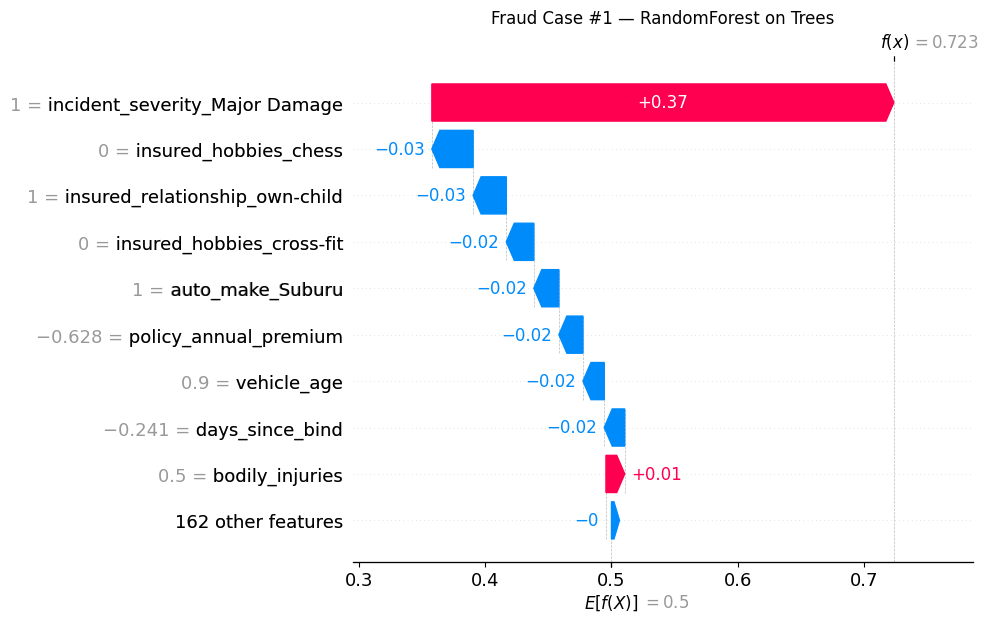

--- Fraud Case #2 (test idx = 3) ---


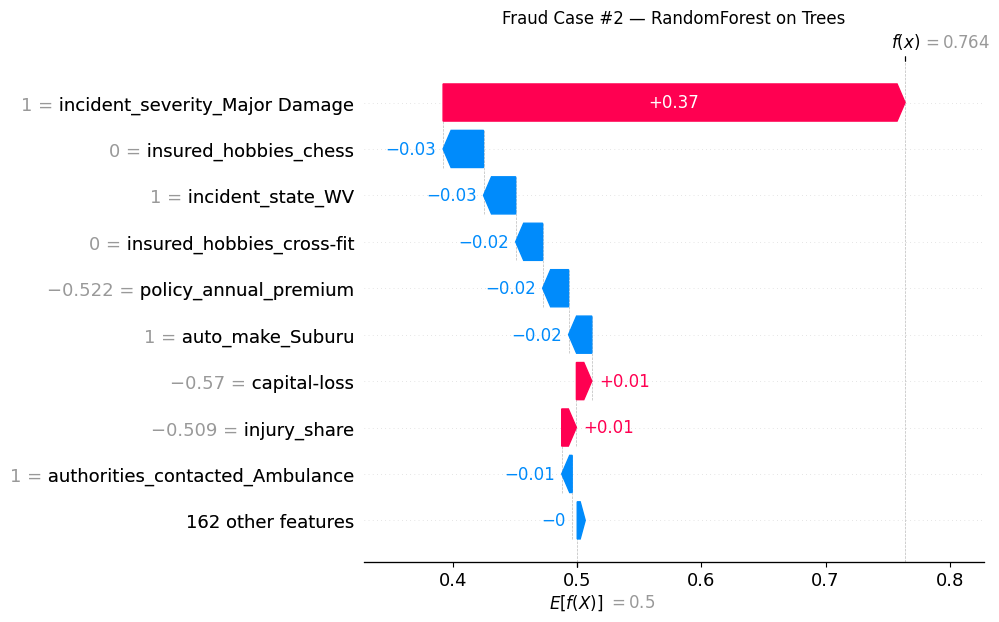

--- Fraud Case #3 (test idx = 6) ---


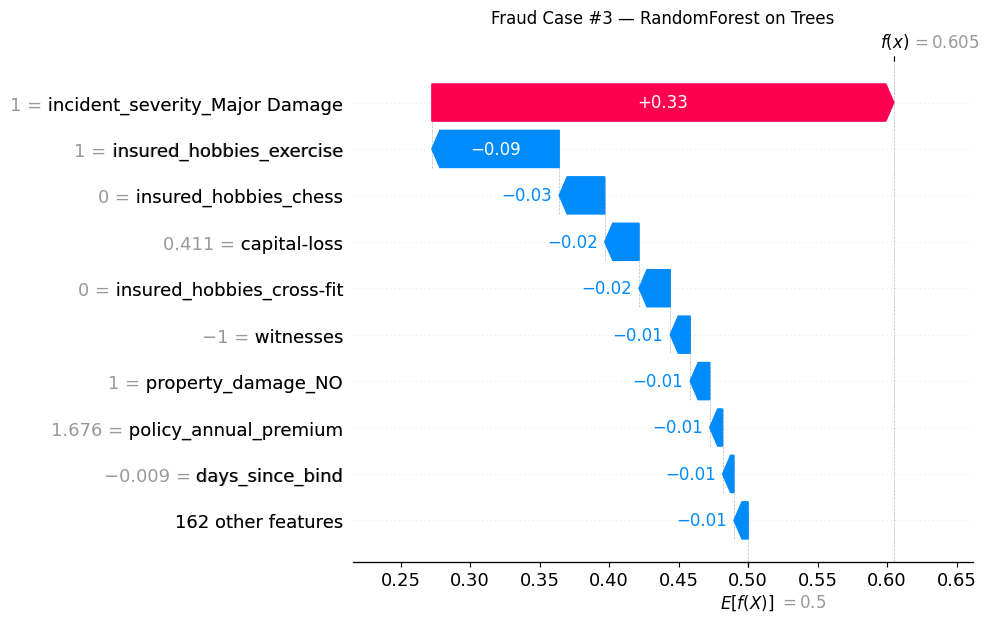

--- Fraud Case #4 (test idx = 7) ---


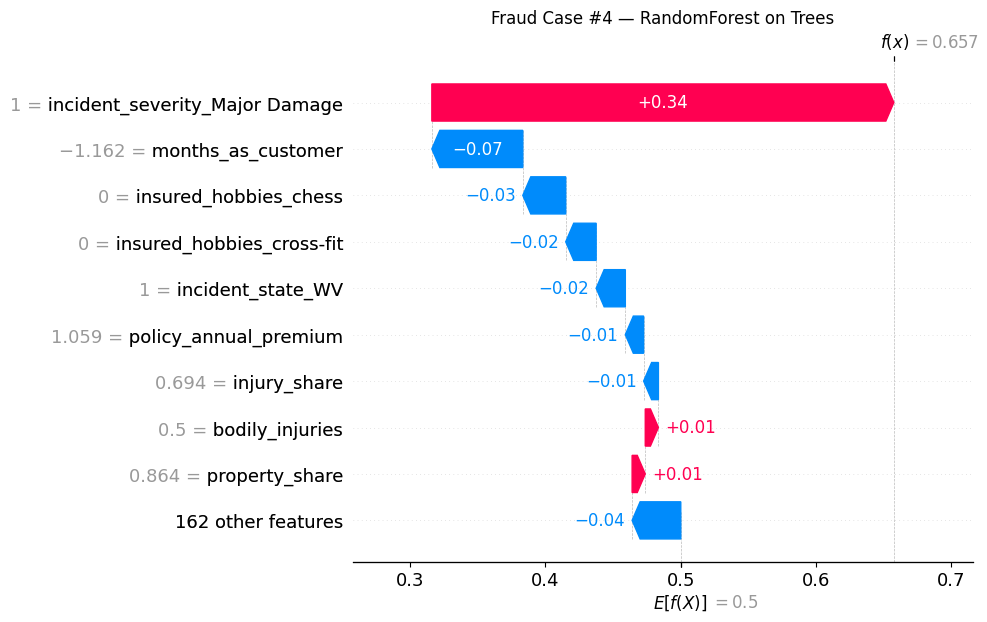

--- Fraud Case #5 (test idx = 12) ---


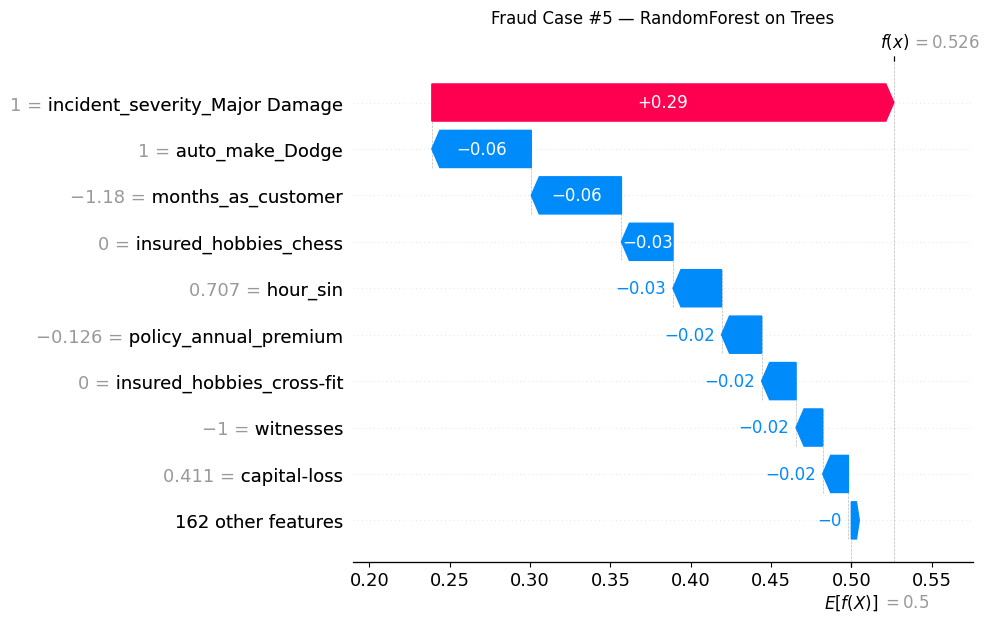

In [30]:
# ============================================================
# MODULE E — INDIVIDUAL CASE SHAP (Waterfalls)
# ------------------------------------------------------------
# Team Rationale:
# - Case-level explanations reveal *why* a specific claim was flagged.
# - Essential for PRD, presentations, and real-world fraud audits.
# ============================================================

print(f"\n### MODULE E — Case-Level SHAP Waterfalls ({model_label}) ###\n")

# ------------------------------------------------------------
# 1. Ensure SHAP explainer exists
# ------------------------------------------------------------
try:
    explainer
except NameError:
    print("Reinitializing SHAP explainer for case-level analysis...")
    explainer = shap.TreeExplainer(clf)

# ------------------------------------------------------------
# 2. Verify model has predict_proba
# ------------------------------------------------------------
if not hasattr(clf, "predict_proba"):
    raise RuntimeError(f"Model {model_label} does not support predict_proba(), "
                       "cannot compute case-level SHAP probabilities.")

# ------------------------------------------------------------
# 3. Compute probabilities & select high-confidence fraud cases
# ------------------------------------------------------------
probs_test = clf.predict_proba(X_test_t)[:, 1]
y_test_arr = y_test.values

# Adjustable threshold — default 0.5
fraud_idx = np.where((probs_test >= 0.5) & (y_test_arr == 1))[0][:5]

if len(fraud_idx) == 0:
    print("⚠️ No fraud cases found above threshold = 0.5.")
    print("Try lowering threshold or increasing the number of cases.\n")

print(f"Plotting {len(fraud_idx)} case waterfalls...\n")

# ------------------------------------------------------------
# 4. Generate waterfall plots for each fraud case
# ------------------------------------------------------------
for rank, idx in enumerate(fraud_idx, start=1):
    print(f"--- Fraud Case #{rank} (test idx = {idx}) ---")

    row = X_test_t[idx].reshape(1, -1)

    shap_row = explainer(row, check_additivity=False)

    # Fix shapes (TreeExplainer returns 3D for binary models)
    if len(shap_row.shape) == 3:
        shap_row = shap_row[:, :, 1]

    shap_row.feature_names = feature_names

    plt.figure(figsize=(9, 6))
    plt.title(f"Fraud Case #{rank} — {model_label}")
    shap.plots.waterfall(shap_row[0], show=True)


In [39]:
# ============================================================
# MODULE F — CLEAN + READABLE FORCE PLOTS (SHAP JS MODE)
# ============================================================

shap.initjs()
js_ready = True

for rank, idx in enumerate(fraud_idx, start=1):

    print(f"--- Force Plot #{rank} ({model_label}, test idx = {idx}) ---")

    # Extract row
    row = X_test_t[idx].reshape(1, -1)

    # SHAP explanation
    shap_row = explainer(row, check_additivity=False)

    # Fix binary class shape
    if len(shap_row.values.shape) == 3:
        shap_row = shap.Explanation(
            values       = shap_row.values[:, :, 1],
            base_values  = shap_row.base_values[:, 1],
            data         = shap_row.data,
            feature_names= feature_names
        )

    # Select top 15 features to avoid unreadable plots
    vals = shap_row.values[0]
    data = shap_row.data[0]
    top_idx = np.argsort(np.abs(vals))[-15:]

    vals_top  = vals[top_idx]
    data_top  = data[top_idx]
    names_top = [feature_names[i] for i in top_idx]

    # JS interactive force plot
    display(
        shap.force_plot(
            shap_row.base_values[0],
            vals_top,
            data_top,
            feature_names=names_top,
            matplotlib=False
        )
    )


--- Force Plot #1 (RandomForest on Trees, test idx = 1) ---


--- Force Plot #2 (RandomForest on Trees, test idx = 3) ---


--- Force Plot #3 (RandomForest on Trees, test idx = 6) ---


--- Force Plot #4 (RandomForest on Trees, test idx = 7) ---


--- Force Plot #5 (RandomForest on Trees, test idx = 12) ---



### MODULE G — Targeted Interactions (RandomForest on Trees) ###

Plotting predefined insurance-relevant interactions...

→ umbrella_limit × incident_severity_Major Damage


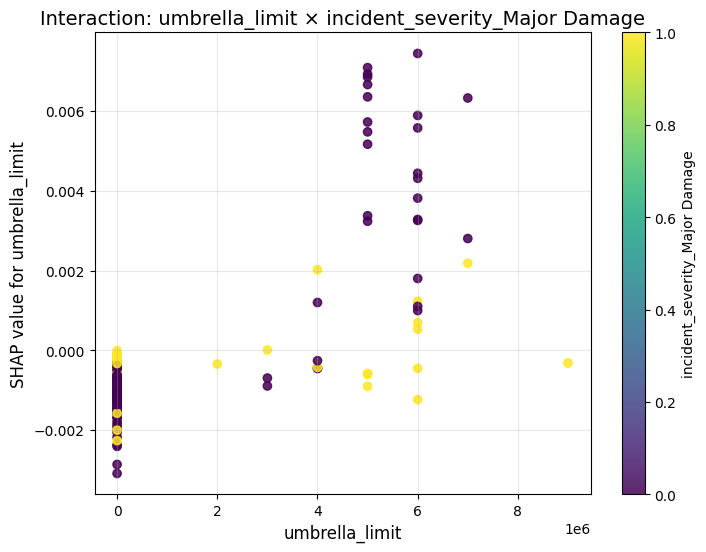

→ total_claim_amount × incident_severity_Major Damage


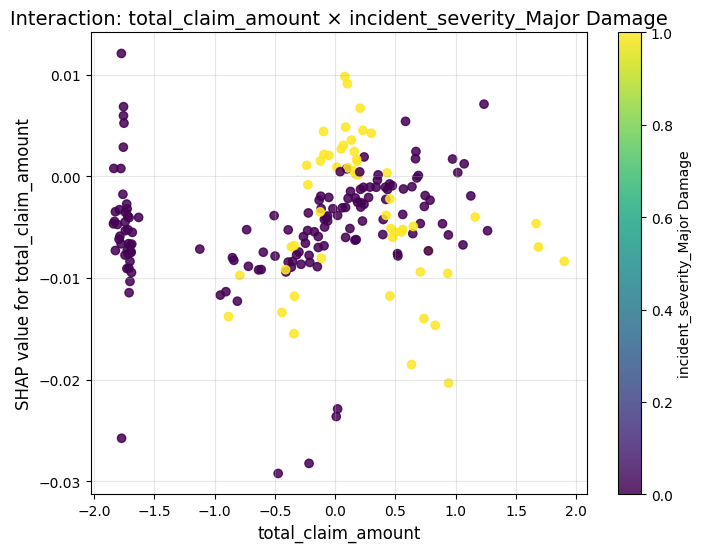

→ vehicle_age × incident_hour_of_the_day


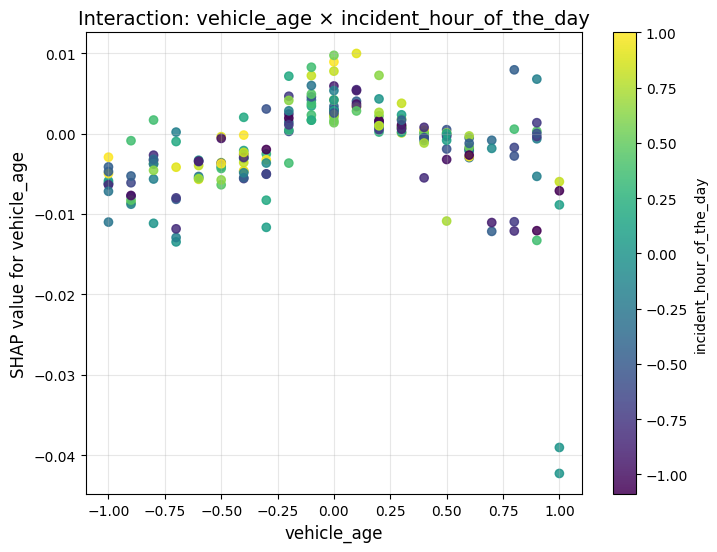

→ policy_annual_premium × months_as_customer


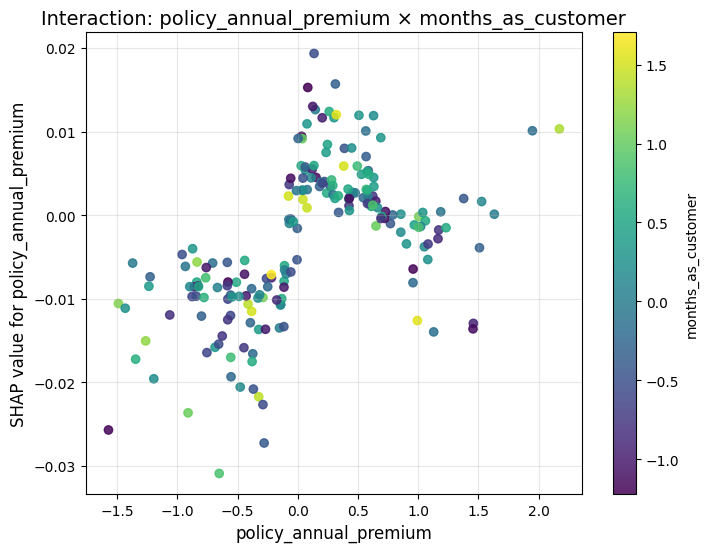

→ policy_annual_premium × injury_share


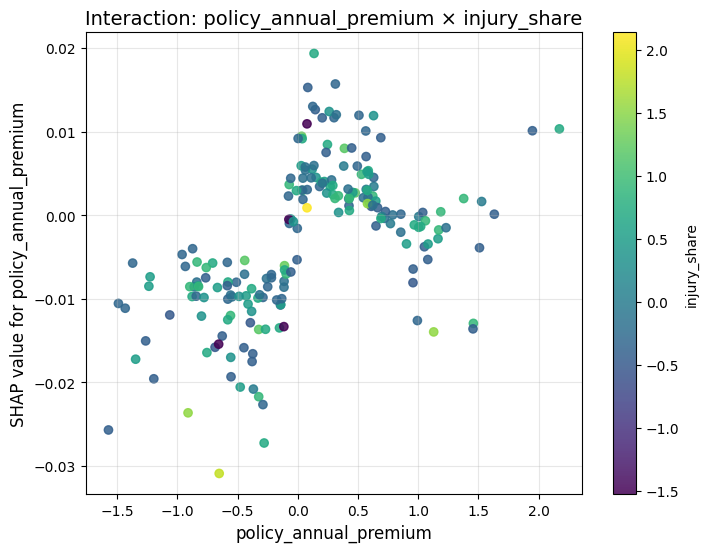

In [40]:
# ============================================================
# MODULE G — TARGETED SHAP INTERACTION VISUALS
# ------------------------------------------------------------
# Team Rationale:
# - These plots reveal nonlinear joint effects between variables.
# - Important for insurance PRD because many fraud patterns arise
#   from *combinations* rather than single features.
# ============================================================

print(f"\n### MODULE G — Targeted Interactions ({model_label}) ###\n")

# Helper: Make a plot for any (feature_x, feature_y) pair
def plot_interaction(feature_x, feature_y):
    if feature_x not in feature_names or feature_y not in feature_names:
        print(f"[SKIPPED] Missing: {feature_x} or {feature_y}")
        return

    ix = feature_names.index(feature_x)
    iy = feature_names.index(feature_y)

    x_val = X_train_t[:200, ix]                      # feature value X
    shap_val = shap_matrix[:200, ix]                # SHAP for X
    y_color = X_train_t[:200, iy]                   # color-coded Y

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x_val, shap_val, c=y_color, cmap="viridis", alpha=0.85)

    plt.title(f"Interaction: {feature_x} × {feature_y}", fontsize=14)
    plt.xlabel(feature_x, fontsize=12)
    plt.ylabel(f"SHAP value for {feature_x}", fontsize=12)
    plt.grid(alpha=0.3)

    cbar = plt.colorbar(scatter)
    cbar.set_label(feature_y)

    plt.show()

# ------------------------------------------------------------
# Example Targeted Interactions (insurance-specific)
# ------------------------------------------------------------

print("Plotting predefined insurance-relevant interactions...\n")

pairs_to_plot = [
    ("umbrella_limit", "incident_severity_Major Damage"),
    ("total_claim_amount", "incident_severity_Major Damage"),
    ("vehicle_age", "incident_hour_of_the_day"),
    ("policy_annual_premium", "months_as_customer"),
    ("policy_annual_premium", "injury_share"),
]

for f1, f2 in pairs_to_plot:
    print(f"→ {f1} × {f2}")
    plot_interaction(f1, f2)


Using MODEL = ExtraTrees on DATASET = Trees
Model class: Pipeline
Detected pipeline. Transforming test data using 'prep'...

Selected 10 fraud cases for waterfall plots.

---- Waterfall for Fraud Case #1 (test idx = 1) ----


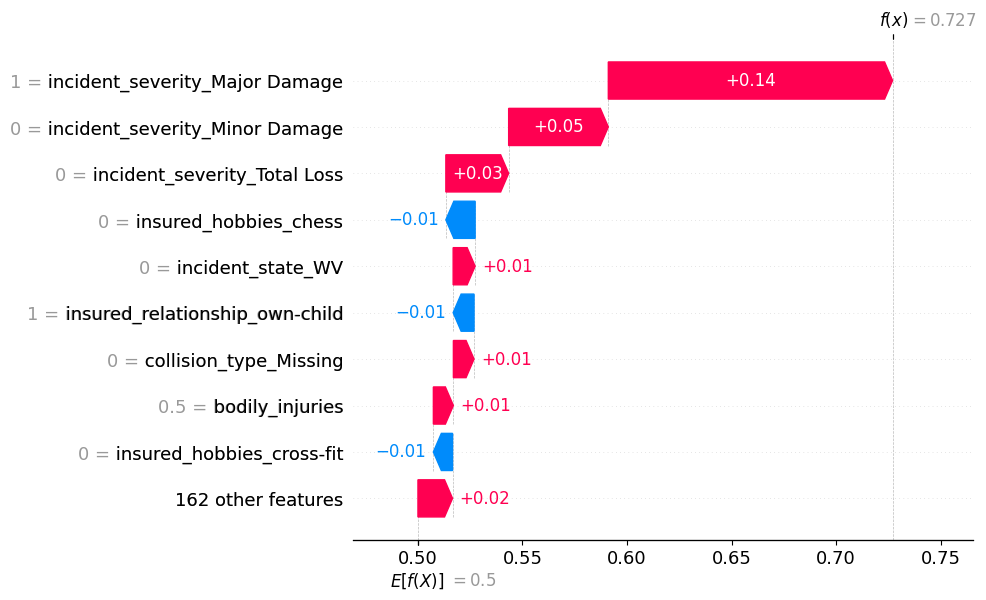


---- Waterfall for Fraud Case #2 (test idx = 3) ----


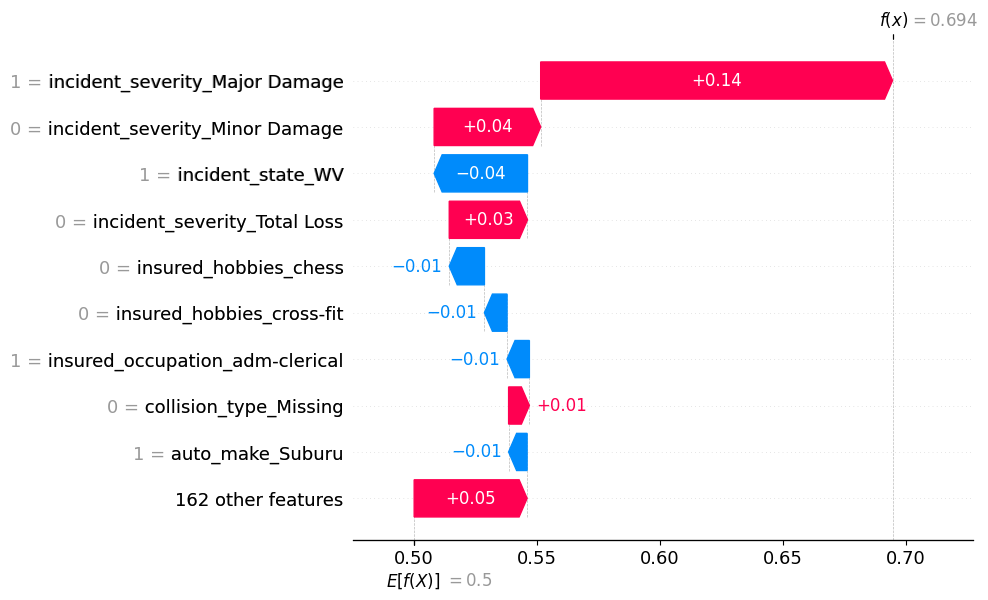


---- Waterfall for Fraud Case #3 (test idx = 6) ----


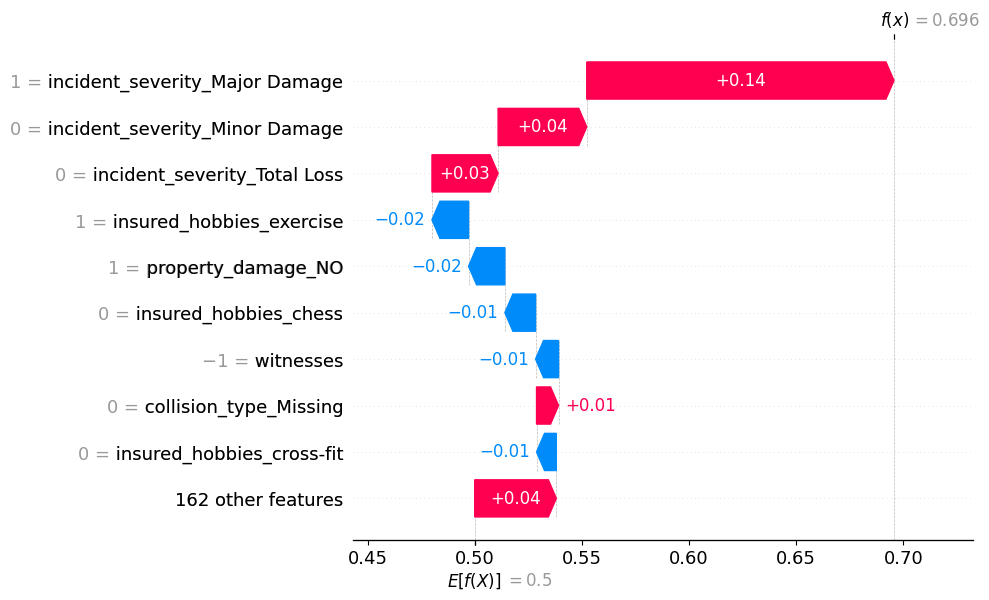


---- Waterfall for Fraud Case #4 (test idx = 7) ----


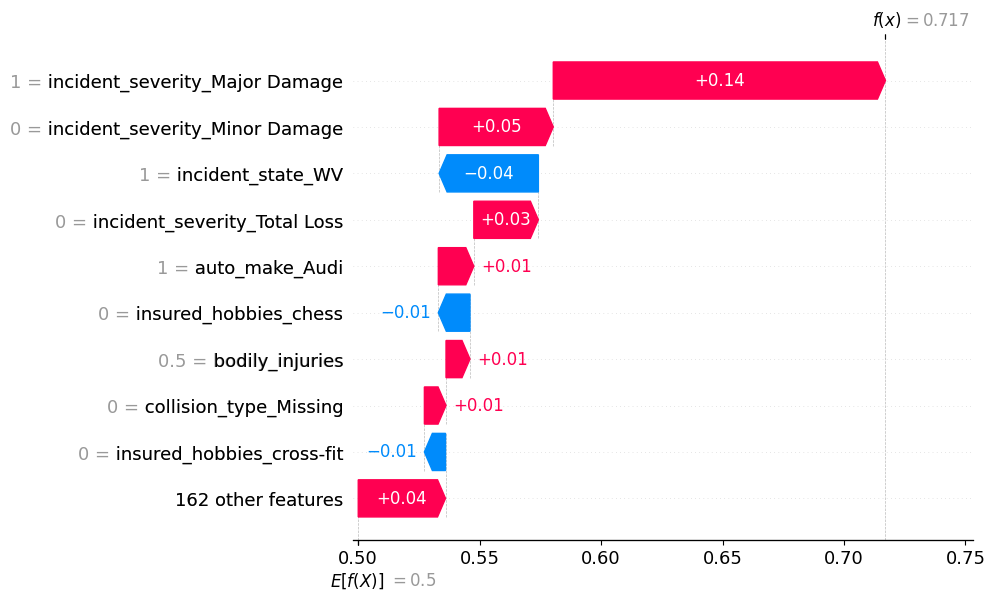


---- Waterfall for Fraud Case #5 (test idx = 12) ----


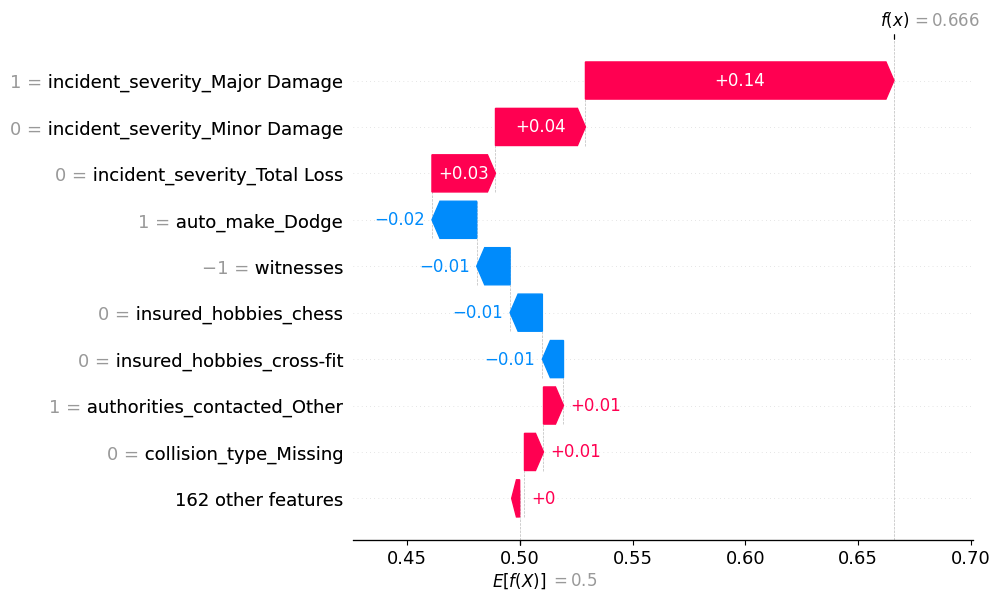


---- Waterfall for Fraud Case #6 (test idx = 13) ----


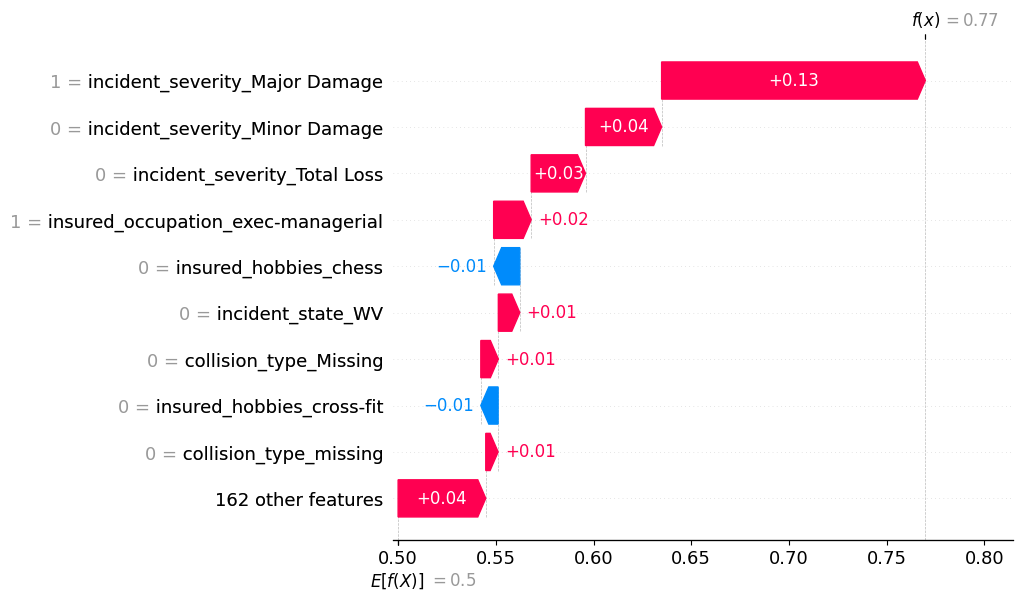


---- Waterfall for Fraud Case #7 (test idx = 20) ----


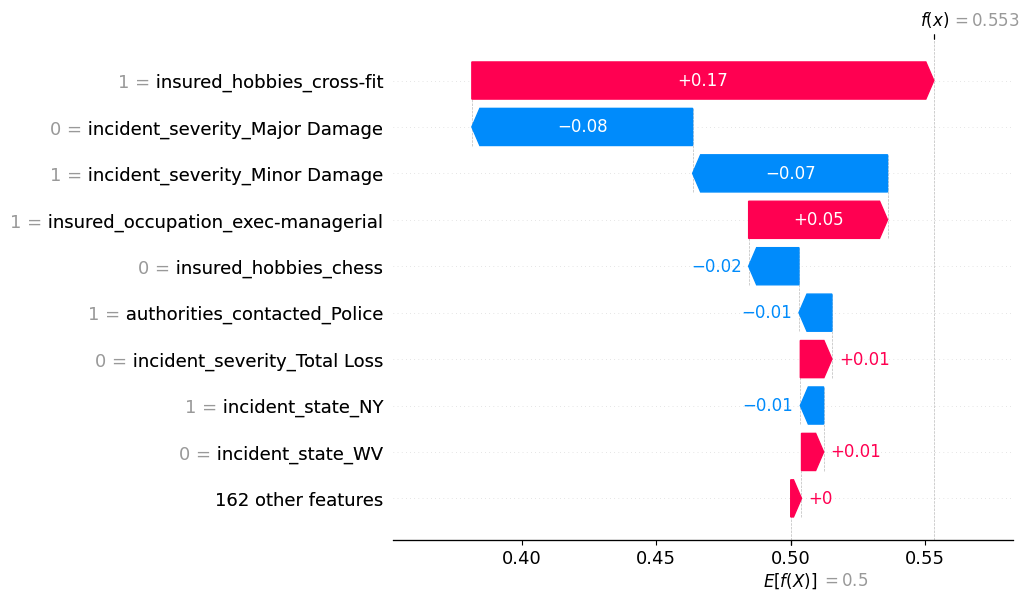


---- Waterfall for Fraud Case #8 (test idx = 21) ----


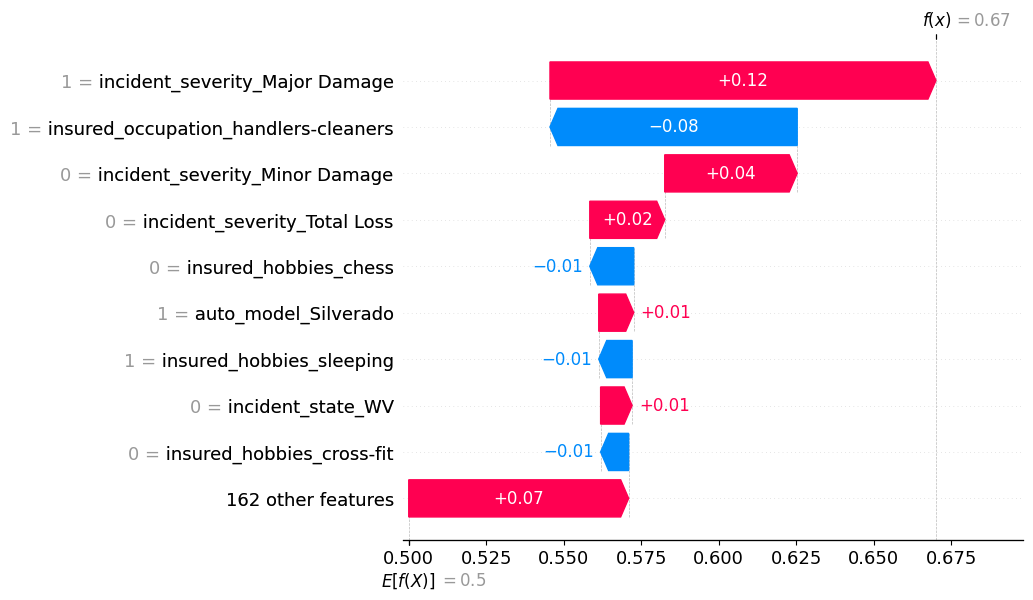


---- Waterfall for Fraud Case #9 (test idx = 31) ----


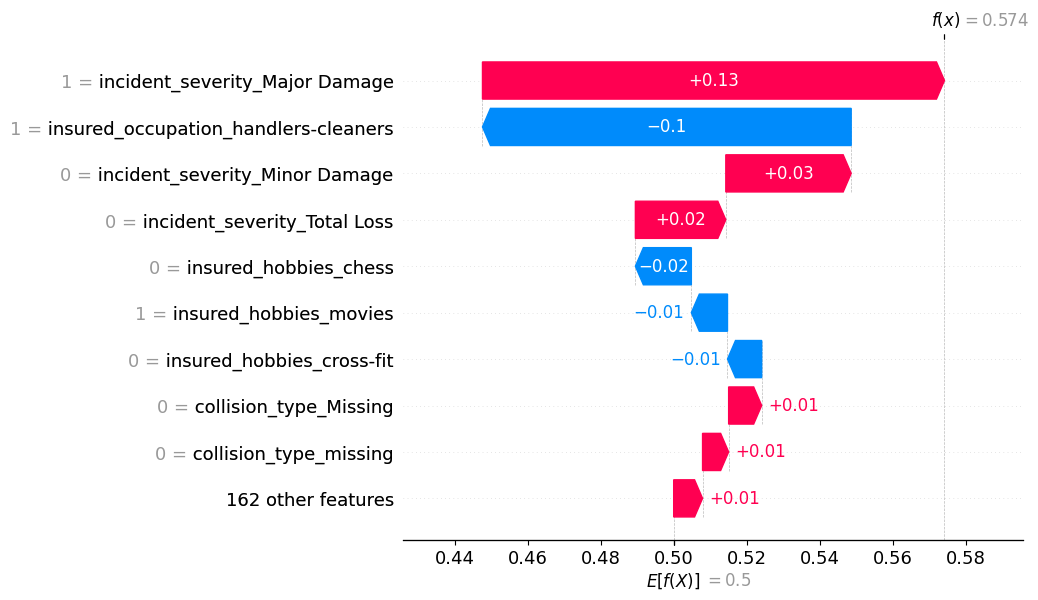


---- Waterfall for Fraud Case #10 (test idx = 36) ----


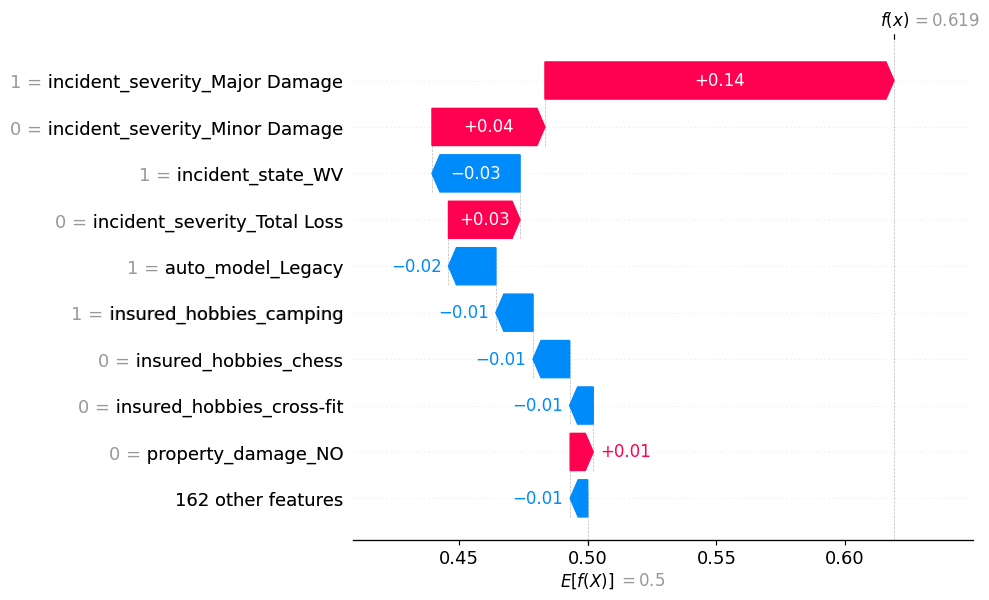

In [8]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
N_CASES = 10
THRESHOLD = 0.5   # show any fraud with predicted prob >= 0.5


# ============================================================================
# 1. SELECT DATASET + MODEL
# ============================================================================

dataset_name = "Trees"
model_name = "ExtraTrees"

df = datasets[dataset_name]
X = df.drop("target", axis=1)
y = df["target"]

calibrated_clf = calibrated_models[dataset_name][model_name]

# Unwrap calibrated classifier if needed
if hasattr(calibrated_clf, "calibrated_classifiers_"):
    model = calibrated_clf.calibrated_classifiers_[0].estimator
else:
    model = calibrated_clf

print(f"Using MODEL = {model_name} on DATASET = {dataset_name}")
print("Model class:", type(model).__name__)


# ============================================================================
# 2. TRAIN–TEST SPLIT
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)


# ============================================================================
# 3. TRANSFORM DATA THROUGH PREPROCESSOR (if pipeline)
# ============================================================================

# Case A: model is inside a pipeline with "prep" and "clf"
if hasattr(model, "named_steps") and "prep" in model.named_steps:
    prep = model.named_steps["prep"]
    clf = model.named_steps["clf"]

    print("Detected pipeline. Transforming test data using 'prep'...")

    X_test_t = prep.transform(X_test)
    if hasattr(X_test_t, "toarray"):
        X_test_t = X_test_t.toarray()

    # Extract feature names
    try:
        feature_names = list(prep.get_feature_names_out())
    except:
        feature_names = [f"f{i}" for i in range(X_test_t.shape[1])]

# Case B: classifier only, no pipeline
else:
    clf = model
    print("No pipeline detected. Using raw features.")
    X_test_t = X_test.values
    feature_names = list(X.columns)


# ============================================================================
# 4. FIND FRAUD CASES ABOVE THRESHOLD
# ============================================================================

probs = clf.predict_proba(X_test_t)[:, 1]
y_true = y_test.values

fraud_indices = np.where((probs >= THRESHOLD) & (y_true == 1))[0]

if len(fraud_indices) == 0:
    raise ValueError("No fraud cases above threshold. Try lowering THRESHOLD.")

fraud_cases = fraud_indices[:N_CASES]
print(f"\nSelected {len(fraud_cases)} fraud cases for waterfall plots.")


# ============================================================================
# 5. SET UP SHAP EXPLAINER
# ============================================================================

explainer = shap.TreeExplainer(clf)

# Extract base value properly
raw_base = explainer.expected_value
if isinstance(raw_base, list) or isinstance(raw_base, np.ndarray):
    base_value = raw_base[1]
else:
    base_value = raw_base


# ============================================================================
# 6. GENERATE WATERFALL PLOTS
# ============================================================================

for plot_i, idx in enumerate(fraud_cases, start=1):
    print(f"\n---- Waterfall for Fraud Case #{plot_i} (test idx = {idx}) ----")

    row = X_test_t[idx].reshape(1, -1)

    # SHAP values for this row
    shap_vals = explainer(row, check_additivity=False)

    # Fix dimensionality issues for binary classification
    if len(shap_vals.shape) == 3:
        shap_vals = shap_vals[:, :, 1]

    shap_vals.feature_names = feature_names

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_vals[0], show=True)
